In [1]:
from collections import deque
import numpy as np
import random
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() \
        else 'mps' if torch.mps.is_available() \
        else 'cpu'

print("Dispositivo disponible:",  DEVICE)


Dispositivo disponible: cuda


In [3]:
class DQNNetwork(nn.Module):
    """
    Red neuronal feedforward para aproximar Q-values.
    
    Arquitectura:
    - Capa de entrada: recibe el estado del entorno
    - 2 capas ocultas Linear con activación ReLU
    - Capa de salida Linear: devuelve Q-value para cada acción posible
    
    Parámetros
    ----------
    state_size : int
        Dimensión del espacio de estados (número de features de observación)
    action_size : int
        Número de acciones posibles
    hidden_size : int, opcional
        Número de neuronas en las capas ocultas (default: 128)
    """
    
    def __init__(self, state_size: int, action_size: int, hidden_size: int = 128):
        super(DQNNetwork, self).__init__()

        # Capa de tipo secuencial que contiene las capas de la red
        # Lineal + ReLU + Lineal + ReLU + Lineal
        self.seq = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size)
        )
        
    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Forward pass de la red.
        
        Parámetros
        ----------
        state : torch.Tensor
            Estado(s) del entorno. Shape: (batch_size, state_size) o (state_size,)
            
        Retorna
        -------
        torch.Tensor
            Q-values para cada acción. Shape: (batch_size, action_size) o (action_size,)
        """
        # Aplica la red neuronal al estado de entrada y devuelve el resultado
        return self.seq(state)


In [4]:
class ReplayBuffer:
    """
    Buffer circular para almacenar y samplear experiencias.
    
    Parámetros
    ----------
    capacity : int
        Tamaño máximo del buffer. Cuando se llena, las experiencias
        más antiguas se eliminan automáticamente.
    """
    
    def __init__(self, capacity: int):
        # Crea un buffer circular usando una cola (deque)
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state: np.ndarray, action: int, reward: float, 
             next_state: np.ndarray, done: bool) -> None:
        """
        Añade una transición al buffer.
        
        Parámetros
        ----------
        state : np.ndarray
            Estado actual
        action : int
            Acción tomada
        reward : float
            Recompensa recibida
        next_state : np.ndarray
            Estado siguiente
        done : bool
            True si el episodio terminó, False en caso contrario
        """
        # Añade al buffer una tupla (estado, acción, recompensa, siguiente estado, terminado)
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size: int):
        """
        Samplea un mini-batch aleatorio de experiencias.
        
        Parámetros
        ----------
        batch_size : int
            Número de experiencias a samplear
            
        Retorna
        -------
        Tuple de arrays numpy:
            - states: (batch_size, state_size)
            - actions: (batch_size,)
            - rewards: (batch_size,)
            - next_states: (batch_size, state_size)
            - dones: (batch_size,)
        """
        # Samplear índices aleatorios
        # Usa random.sample para elegir un batch de tuplas
        batch = random.sample(self.buffer, batch_size)
        
        # Desempaquetar el batch en arrays separados
        states, actions, rewards, next_states, dones = zip(*batch)
        
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32)
        )
    
    def __len__(self) -> int:
        """Retorna el número de experiencias actualmente en el buffer."""
        return len(self.buffer)


In [5]:
def epsilon_greedy_policy(policy_net: DQNNetwork, state: np.ndarray, epsilon: float, action_size: int) -> int:
    """
    Selecciona una acción usando epsilon-greedy policy.
    
    Con probabilidad epsilon elige una acción aleatoria (exploración), y con probabilidad 
    1-epsilon elige la  mejor acción según la red (explotación).
    
    Parámetros
    ----------
    policy_net : DQNNetwork
        Red neuronal que representa la política del agente
    state : np.ndarray
        Estado actual del entorno como array
    epsilon : float
        Probabilidad de elegir una acción aleatoria
    action_size : int
        Número de acciones disponibles en el entorno
        
    Retorna
    -------
    int
        Acción seleccionada
    """
    # Exploración: acción aleatoria
    if np.random.random() < epsilon:
        # Devolver acción aleatoria con np.random.randint
        return np.random.randint(action_size)
    
    # Explotación: mejor acción según Q-values
    with torch.no_grad():
        # Transformar el estado a un tensor
        state = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)

        # aplicar la red al estado para obtener los valores q
        q_values = policy_net.forward(state)
        
        # devolver el índice del mayor valor Q (como int)
        return q_values.argmax().item()
    

In [6]:
def train_step(policy_net: DQNNetwork, 
               target_net: DQNNetwork, 
               gamma: float, 
               optimizer: torch.optim.Optimizer, 
               memory: ReplayBuffer, 
               batch_size: int) -> float:
    """
    Ejecuta un paso de entrenamiento con un mini-batch del replay buffer.
    
    Implementa la actualización de Q-learning:
    Q(s,a) ← Q(s,a) + α[r + γ max_a' Q_target(s',a') - Q(s,a)]
    
    Parámetros
        ----------
        policy_net : DQNNetwork
            Red neuronal que representa la política del agente (entrenada)
        target_net : DQNNetwork
            Red neuronal objetivo (fija temporalmente)
        gamma : float
            Factor de descuento para recompensas futuras
        optimizer : torch.optim.Optimizer
            Optimizador para actualizar los pesos de la red
        memory : ReplayBuffer
            Buffer de experiencias para samplear mini-batches
        batch_size : int
            Tamaño del mini-batch de entrenamiento
        
    Retorna
    -------
    float
        Pérdida (loss) del paso de entrenamiento, o 0.0 si no hay
        suficientes experiencias en el buffer
    """
    # No entrenar si no hay suficientes experiencias
    if len(memory) < batch_size:
        return 0.0
    
    # Samplear mini-batch del replay buffer
    states, actions, rewards, next_states, dones = memory.sample(batch_size)
    assert len(states) == batch_size
    
    # Convertir a tensores de PyTorch
    states = torch.FloatTensor(states).to(DEVICE)
    actions = torch.LongTensor(actions).to(DEVICE)
    rewards = torch.FloatTensor(rewards).to(DEVICE)
    next_states = torch.FloatTensor(next_states).to(DEVICE)
    dones = torch.FloatTensor(dones).to(DEVICE)
    
    # Q-values actuales: Q(s,a) para las acciones tomadas
    # aplicar la policy_net a los estados del mini batch y obtener sus valores Q
    current_q_values = policy_net.forward(states)
    # seleccionar los valores Q de la acción tomada en cada estado
    current_q_values = current_q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Q-values objetivo: r + γ max_a' Q_target(s',a')
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0]
        # Si dones = 1 no hay estado siguiente y target_q_values = rewards
        target_q_values = rewards + (1 - dones) * gamma * next_q_values
    
    # Calcular pérdida y actualizar pesos
    # Usa F.mse_loss para calcular el error entre current_q_values y target_q_values
    loss = F.mse_loss(current_q_values, target_q_values)
    
    # minimizar el error
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [7]:
def copy_weights(policy_net: DQNNetwork, target_net: DQNNetwork) -> None:
    """Copia los pesos de la policy network a la target network."""
    # Usa el método state_dict() para obtener los pesos de una red
    # Usa el método load_state_dict() para establecer los pesos de una red
    target_net.load_state_dict(policy_net.state_dict())


In [8]:
def train(env: gym.Env, n_episodes: int, lr: float, gamma: float, 
          epsilon: float, epsilon_decay: float, epsilon_min: float, 
          memory_size: int, batch_size: int, 
          target_update_steps: int, 
          print_every: int,
          final_model_path: str):
    """
    Entrena un agente DQN en el entorno especificado.

    Parámetros
    ----------
    env : gym.Env
        Entorno de OpenAI Gymnasium.
    n_episodes : int
        Número de episodios de entrenamiento.
    lr : float
        Tasa de aprendizaje para el optimizador.
    gamma : float
        Factor de descuento para recompensas futuras.
    epsilon : float
        Valor inicial de epsilon para la política epsilon-greedy.
    epsilon_decay : float
        Factor de decaimiento de epsilon por episodio.
    epsilon_min : float
        Valor mínimo de epsilon.
    memory_size : int
        Capacidad máxima del replay buffer.
    batch_size : int
        Tamaño del mini-batch para entrenamiento.
    target_update_steps : int
        Frecuencia (en pasos) para actualizar la red objetivo.
    print_every : int
        Frecuencia (en episodios) para imprimir métricas de entrenamiento.

    Retorna
    -------
    policy_net : DQNNetwork
        Red neuronal entrenada que representa la política aprendida.
    """
    
    obs_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    # Redes
    policy_net = DQNNetwork(obs_size, action_size).to(DEVICE)
    target_net = DQNNetwork(obs_size, action_size).to(DEVICE)
    copy_weights(policy_net, target_net)
    target_net.eval()
    
    # Optimizador
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)

    # Replay buffer
    memory = ReplayBuffer(memory_size)

    # Estadísticas
    episode_rewards = []
    episode_losses = []
    avg_rewards = []
    steps = 0

    print("Iniciando entrenamiento...")
    for episode in range(n_episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_loss = []
        done = False
        while not done:
            # Seleccionar y ejecutar acción
            action = epsilon_greedy_policy(policy_net, state, epsilon, action_size)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Almacenar experiencia
            memory.push(state, action, reward, next_state, done)

            # Entrenamiento
            loss = train_step(policy_net, target_net, gamma, optimizer, memory, batch_size)
            steps += 1

            # Actualización de la target_net
            if steps % target_update_steps == 0:
                copy_weights(policy_net, target_net)

            if loss > 0:
                episode_loss.append(loss)
            episode_reward += reward

            state = next_state
        
        # Disminuir epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Guardar métricas
        episode_rewards.append(episode_reward)
        avg_loss = np.mean(episode_loss) if episode_loss else 0
        episode_losses.append(avg_loss)
        
        # Promedio móvil
        avg_reward = np.mean(episode_rewards[-100:])
        avg_rewards.append(avg_reward)

        # Imprimir progreso
        if episode % print_every == 0:
            print(f"Episodio {episode:4d} | Recompensa: {episode_reward:6.1f} | "
                f"Avg(100): {avg_reward:6.2f} | Epsilon: {epsilon:.3f} | Loss: {avg_loss:.4f}")

    print("\n¡Entrenamiento completado!")
    
    # Salvar modelo
    torch.save(policy_net, final_model_path)
    print(f"\nModelo salvado en {final_model_path}")

    return episode_rewards, avg_rewards, episode_losses, avg_loss


In [9]:
import os

os.makedirs("./models/", exist_ok=True)

# Configuración de entrenamiento
env = gym.make('CartPole-v1', render_mode="rgb_array")
n_episodes = 500
lr = 0.001
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
memory_size = 10_000
batch_size = 64
target_update_steps = 20
print_every = 50
final_model_path = 'models/dqn_cartpole'

episode_rewards, avg_rewards, episode_losses, avg_loss = train(
    env, n_episodes, lr, gamma, epsilon, epsilon_decay, epsilon_min, 
    memory_size, batch_size, target_update_steps, print_every, final_model_path)


Iniciando entrenamiento...
Episodio    0 | Recompensa:   10.0 | Avg(100):  10.00 | Epsilon: 0.995 | Loss: 0.0000
Episodio   50 | Recompensa:   94.0 | Avg(100):  33.20 | Epsilon: 0.774 | Loss: 52.1724
Episodio  100 | Recompensa:   51.0 | Avg(100):  43.66 | Epsilon: 0.603 | Loss: 657.3782
Episodio  150 | Recompensa:   78.0 | Avg(100):  78.02 | Epsilon: 0.469 | Loss: 884.8264
Episodio  200 | Recompensa:  229.0 | Avg(100): 122.40 | Epsilon: 0.365 | Loss: 199.5212
Episodio  250 | Recompensa:  183.0 | Avg(100): 140.02 | Epsilon: 0.284 | Loss: 83.0997
Episodio  300 | Recompensa:  159.0 | Avg(100): 188.21 | Epsilon: 0.221 | Loss: 38.3260
Episodio  350 | Recompensa:  130.0 | Avg(100): 232.71 | Epsilon: 0.172 | Loss: 42.2512
Episodio  400 | Recompensa:  500.0 | Avg(100): 236.80 | Epsilon: 0.134 | Loss: 26.8929
Episodio  450 | Recompensa:  315.0 | Avg(100): 231.27 | Epsilon: 0.104 | Loss: 30.9303

¡Entrenamiento completado!

Modelo salvado en models/dqn_cartpole


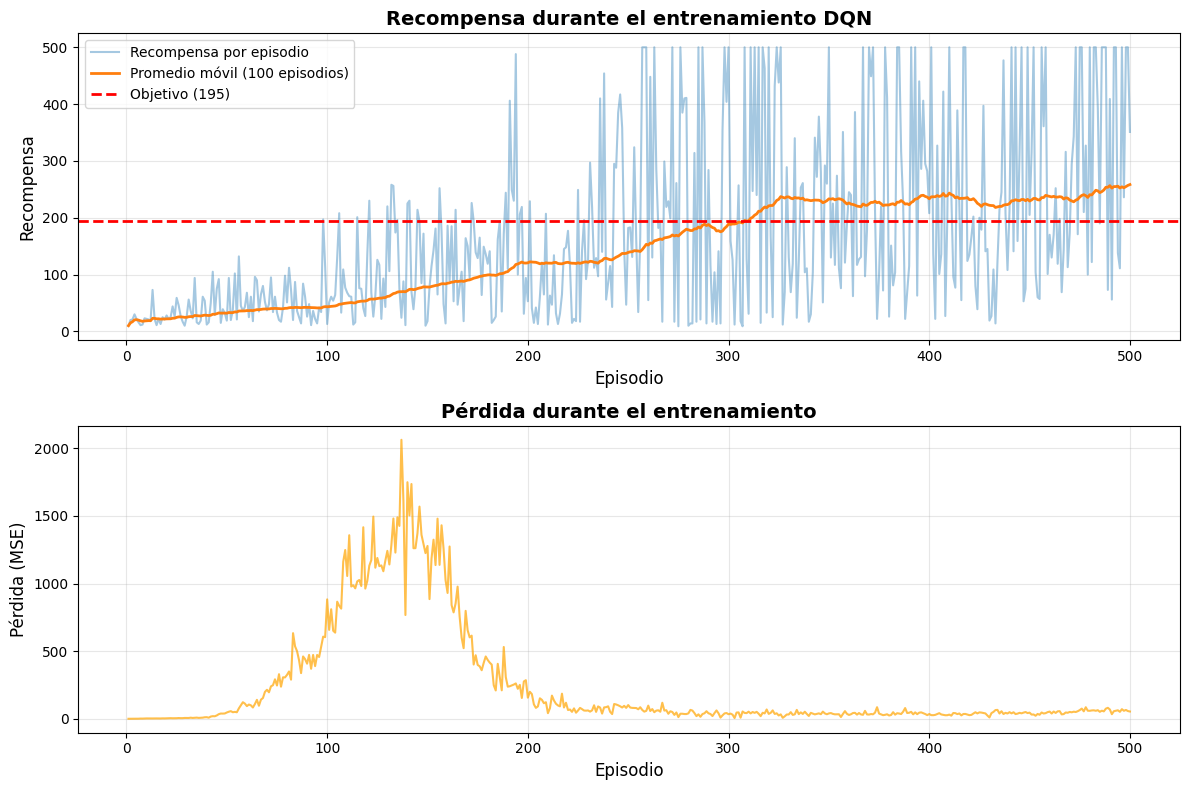


Estadísticas finales:
  Total de episodios: 500
  Recompensa máxima: 500
  Recompensa promedio (últimos 100): 258.40


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Gráfica de recompensas
episodes = range(1, len(episode_rewards) + 1)
ax1.plot(episodes, episode_rewards, alpha=0.4, label='Recompensa por episodio')
ax1.plot(episodes, avg_rewards, linewidth=2, label='Promedio móvil (100 episodios)')
ax1.axhline(y=195, color='r', linestyle='--', linewidth=2, label='Objetivo (195)')
ax1.set_xlabel('Episodio', fontsize=12)
ax1.set_ylabel('Recompensa', fontsize=12)
ax1.set_title('Recompensa durante el entrenamiento DQN', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica de pérdida
ax2.plot(episodes, episode_losses, alpha=0.7, color='orange')
ax2.set_xlabel('Episodio', fontsize=12)
ax2.set_ylabel('Pérdida (MSE)', fontsize=12)
ax2.set_title('Pérdida durante el entrenamiento', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas finales
print(f"\nEstadísticas finales:")
print(f"  Total de episodios: {len(episode_rewards)}")
print(f"  Recompensa máxima: {max(episode_rewards):.0f}")
print(f"  Recompensa promedio (últimos 100): {np.mean(episode_rewards[-100:]):.2f}")


In [11]:
def play_episode(env: gym.Env, policy_net: DQNNetwork):
    """
    Simula un episodio usando una política e-greedy.

    Parámetros:
        env: entorno de gym.
        policy_net: red que define la política del agente.

    Devuelve:
        Tupla (recompensa_total, pasos_totales) .
    """
    state, info = env.reset()
    episode_steps = episode_reward = 0
    done = False
    while not done:
        # Selecciona la acción adecuada usando la función epsilon_greedy_policy
        # IMPORTANTE: epsilon tiene que ser 0 para que no haga acciones aleatorias
        action = epsilon_greedy_policy(policy_net,state,0,env.action_space.n)

        next_state, reward, terminated, truncated, info = env.step(action)
        episode_steps += 1
        episode_reward += reward
        done = terminated or truncated
        state = next_state
    return episode_reward, episode_steps


In [16]:
# Cargar el modelo entrenado
policy_net = torch.load(final_model_path, weights_only=False)
policy_net.eval()

env = gym.make("CartPole-v1", render_mode="human")

# Ejecutar una partida 
episode_reward, episode_steps = play_episode(env, policy_net)
print(f"Recompensa del episodio: {episode_reward}")
print(f"Pasos del episodio: {episode_steps}")

env.close()


Recompensa del episodio: 500.0
Pasos del episodio: 500
